In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [2]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from tqdm import tqdm
from torch_geometric_temporal.nn.recurrent import A3TGCN
import torch.nn.functional as F
import torch.nn as nn
import torch
from src.models.modelcore import DeepLearningModelCore
from src.dataloading.gnndataloader import GNNDataLoader
from typing import Optional


class RecurrentGCN(nn.Module):
    def __init__(self, node_features, periods):
        super(RecurrentGCN, self).__init__()
        self.recurrent = A3TGCN(node_features, 128, periods)
        self.linear = nn.Linear(128, 1)

    def forward(self, x, edge_index, edge_weight):
        x = x.squeeze(2)
        h = self.recurrent(x.view(x.shape[0], 1, x.shape[1]), edge_index, edge_weight)
        h = F.relu(h)
        h = self.linear(h)
        return h.squeeze(1)
        

class PyTorchExample(DeepLearningModelCore):
    """
    Purely spatial GCN model wrapper (no temporal modeling).
    """
    def __init__(self, dataloader: GNNDataLoader, name: Optional[str] = None):
        super().__init__(dataloader, name=name)
        if not self.name:
            self.name = 'pytorch ex'

        self.model_color = '#4ECDC4'
        self.dataloader = dataloader

    def set_model_hparams(self):
        self.model = RecurrentGCN(
            node_features=1,
            periods = 8, 
        ).to(self.device)
        self.model_hparams_set = True
        return self

In [14]:
n_periods = 1
n_epochs  = 50
horizon   = 1
lags      = range(0,7)


epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(lags = lags)

gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
gnnloader4 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Dataloader Snapshot: Data(x=[411, 8, 1], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 3.1433, val loss: 4.0465 ✓ (new best)
Epoch 2 train loss: 3.1001, val loss: 3.9485 ✓ (new best)
Epoch 3 train loss: 3.0576, val loss: 3.8610 ✓ (new best)
Epoch 4 train loss: 3.0155, val loss: 3.7805 ✓ (new best)
Epoch 5 train loss: 2.9754, val loss: 3.7060 ✓ (new best)
Epoch 6 train loss: 2.9373, val loss: 3.6363 ✓ (new best)
Epoch 7 train loss: 2.9008, val loss: 3.5707 ✓ (new best)
Epoch 8 train loss: 2.8658, val loss: 3.5087 ✓ (new best)
Epoch 9 train loss: 2.8440, val loss: 3.4448 ✓ (new best)
Epoch 10 train loss: 2.8043, val loss: 3.3927 ✓ (new best)
Epoch 11 train loss: 2.7738, val loss: 3.3414 ✓ (new best)
Epoch 12 train loss: 2.7436, val loss: 3.2916 ✓ (new best)
Epoch 13 train loss: 2.7151, val loss: 3.2448 ✓ (new best)
Epoch 14 train loss: 2.6879, val loss: 3.2000 ✓ (new best)
Epoch 15 train loss: 2.6854, val loss: 3.1515 ✓ (new best)
Epoch 16 train loss: 2.6474, 

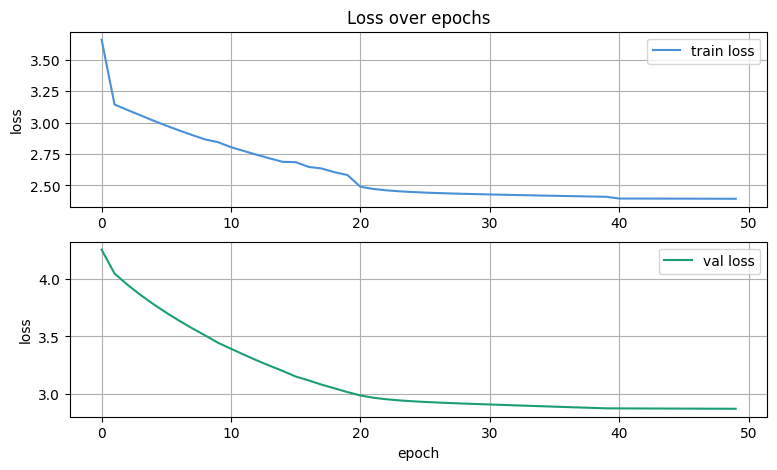

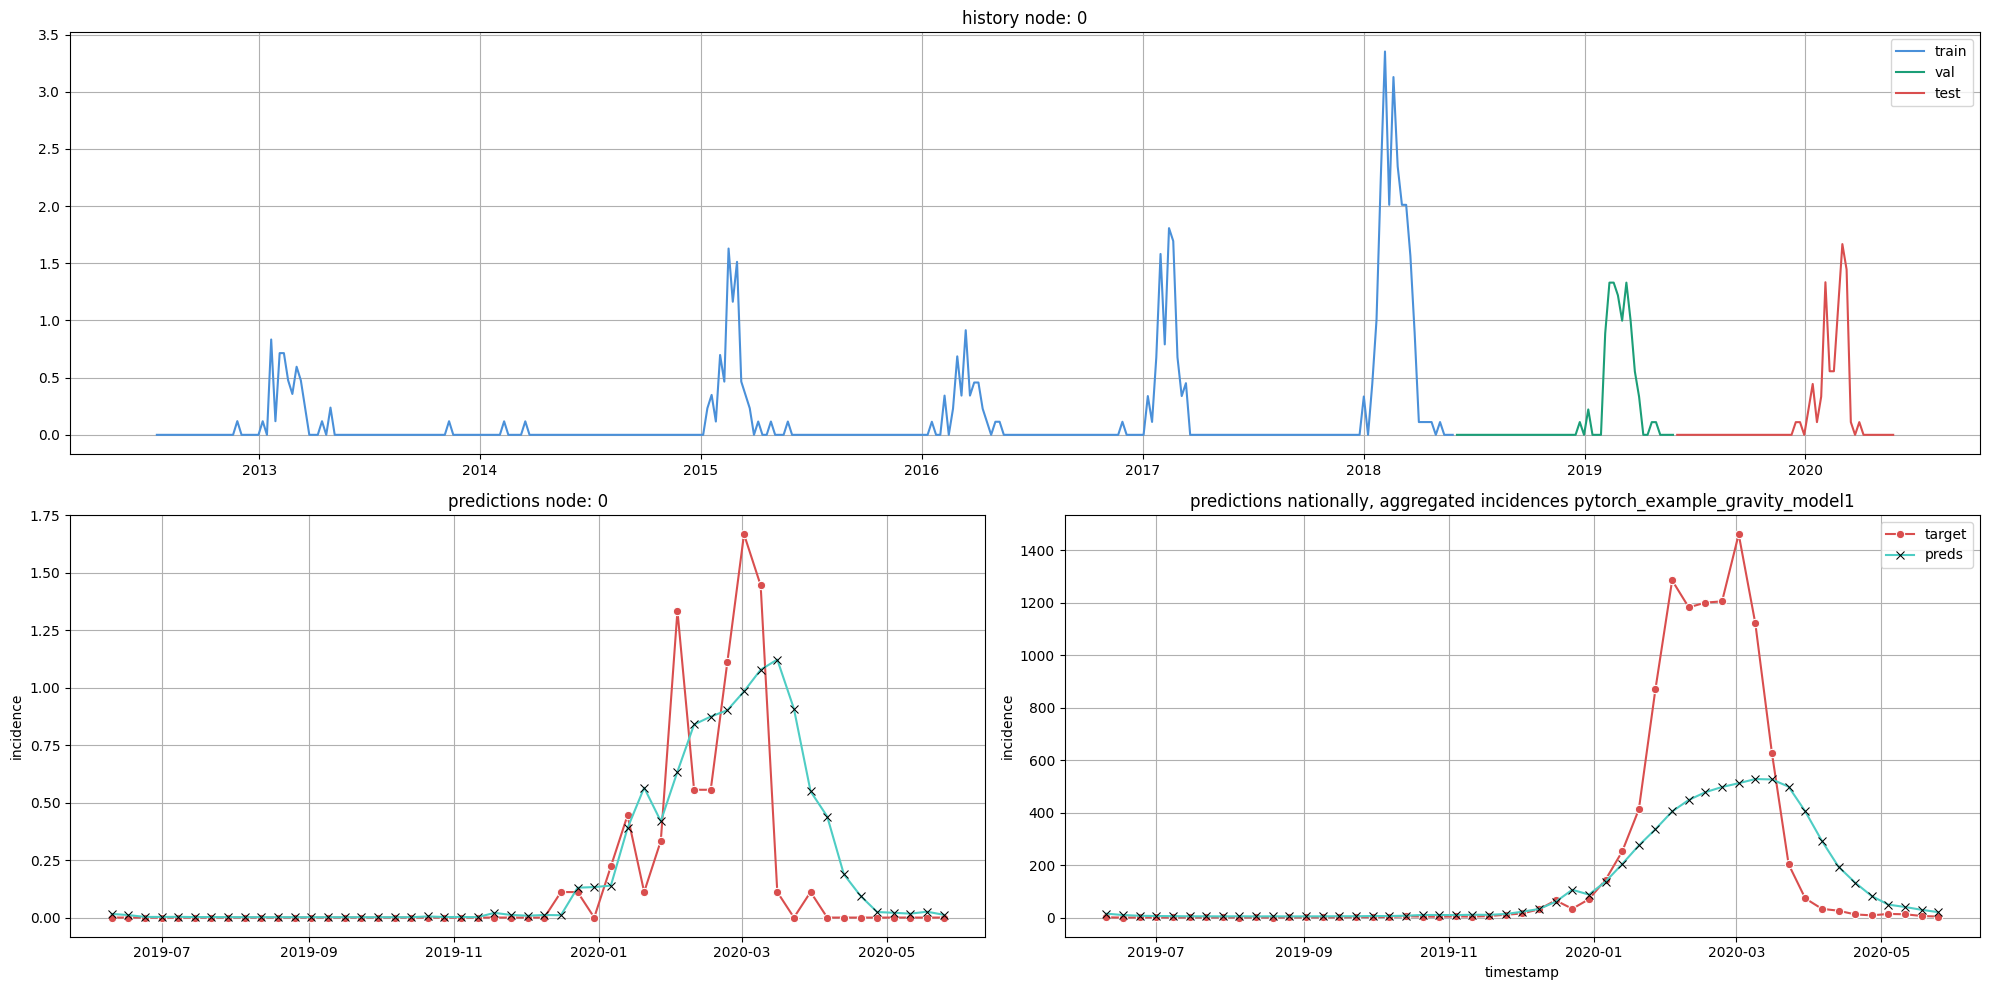

In [22]:
from tests import *

n_epochs = 50
pytorch_run = PyTorchExample(name = 'pytorch_example_gravity_model1', dataloader=gnnloader3)
pytorch_run.set_model_hparams()
pytorch_run.set_global_hparams(lr = 0.0005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001, loss = 'spike_weighted_mse')
pytorch_run.train()
pytorch_run.forecast()
pytorch_run.show_forecasts()

validator = GraphUsageValidator(pytorch_run)
validator.run_tests()

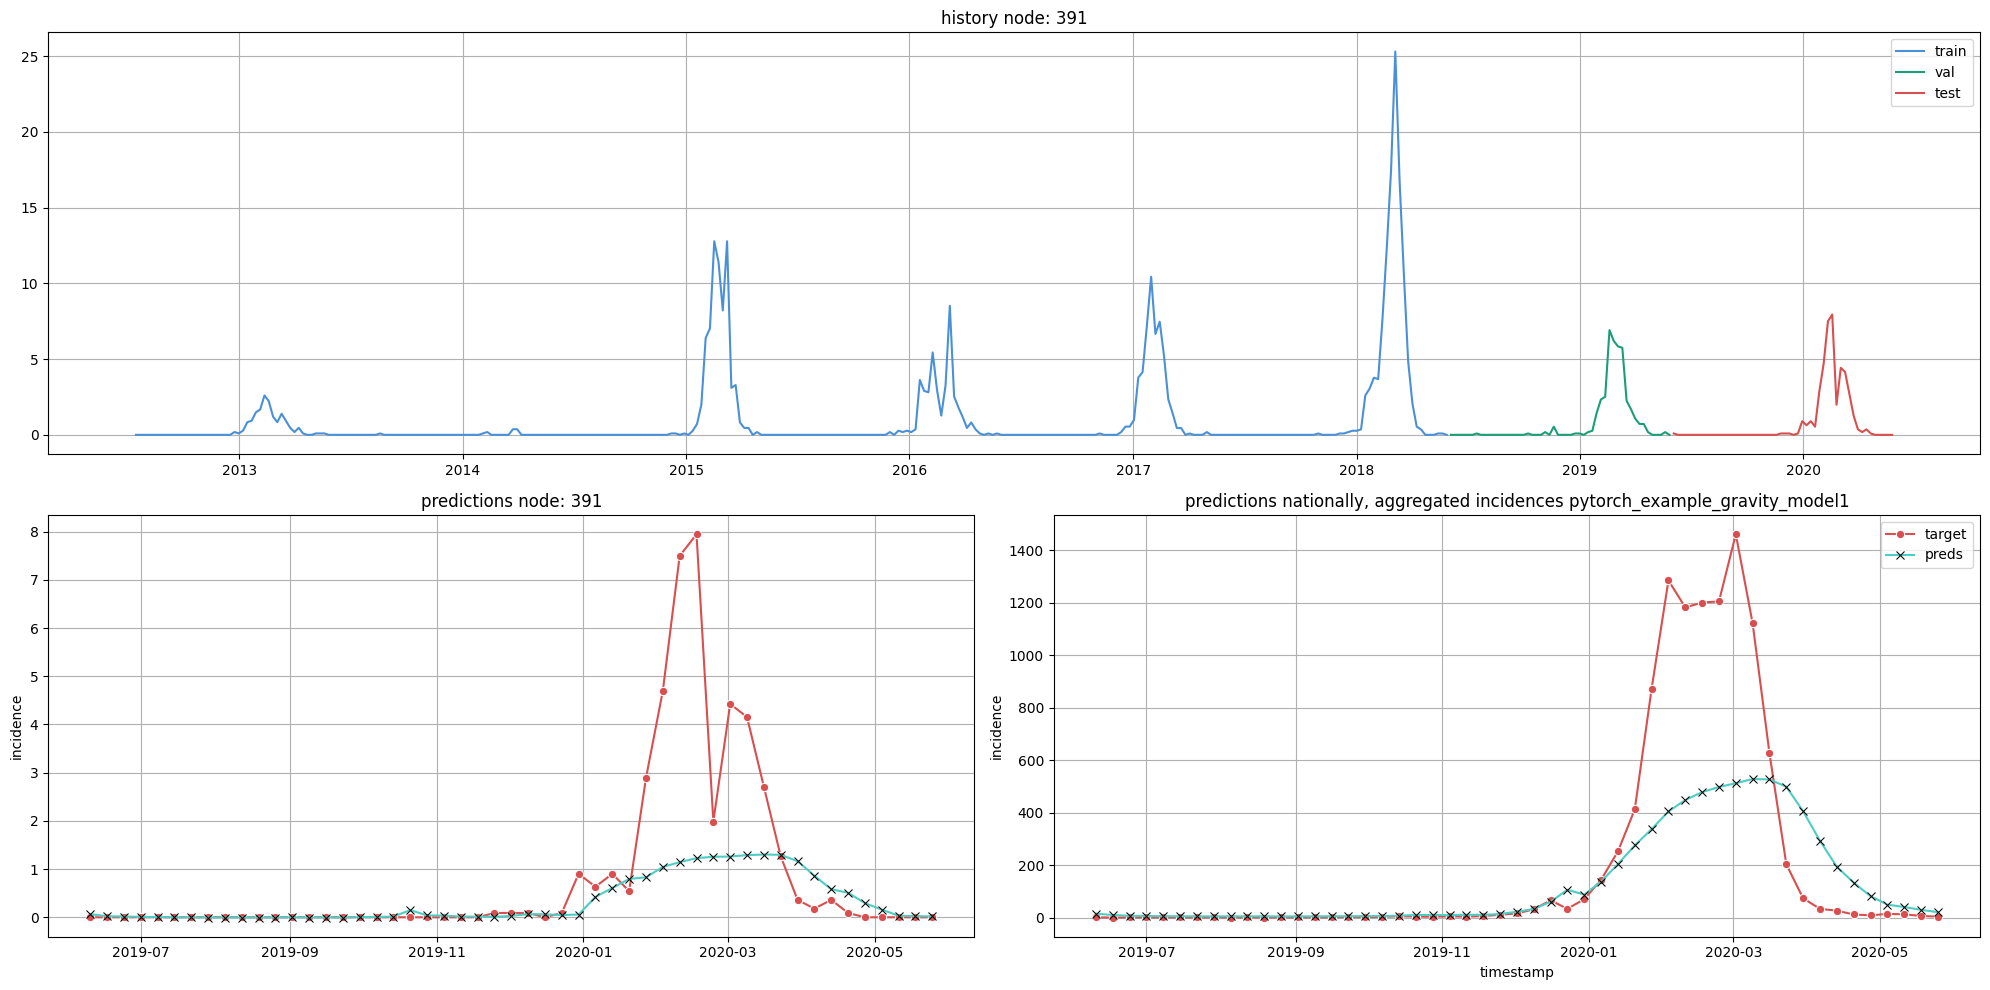

In [23]:
pytorch_run.show_forecasts(391)

single snapshot: Data(x=[399, 5, 1], edge_index=[2, 2469], y=[399], edge_weight=[2469])
Epoch 0 train MSE: 0.9080, val MSE: 5.8206 ✓ (new best)
Epoch 1 train MSE: 0.8758, val MSE: 5.3514 ✓ (new best)
Epoch 2 train MSE: 0.8466, val MSE: 4.8217 ✓ (new best)
Epoch 3 train MSE: 0.8190, val MSE: 4.2665 ✓ (new best)
Epoch 4 train MSE: 0.7944, val MSE: 3.7353 ✓ (new best)
Epoch 5 train MSE: 0.7739, val MSE: 3.2724 ✓ (new best)
Epoch 6 train MSE: 0.7585, val MSE: 2.9057 ✓ (new best)
Epoch 7 train MSE: 0.7478, val MSE: 2.6369 ✓ (new best)
Epoch 8 train MSE: 0.7407, val MSE: 2.4502 ✓ (new best)
Epoch 9 train MSE: 0.7359, val MSE: 2.3244 ✓ (new best)
Epoch 10 train MSE: 0.7326, val MSE: 2.2414 ✓ (new best)
Epoch 11 train MSE: 0.7300, val MSE: 2.1873 ✓ (new best)
Epoch 12 train MSE: 0.7279, val MSE: 2.1529 ✓ (new best)
Epoch 13 train MSE: 0.7261, val MSE: 2.1319 ✓ (new best)
Epoch 14 train MSE: 0.7245, val MSE: 2.1198 ✓ (new best)
Epoch 15 train MSE: 0.7230, val MSE: 2.1140 ✓ (new best)
Epoch 16 t

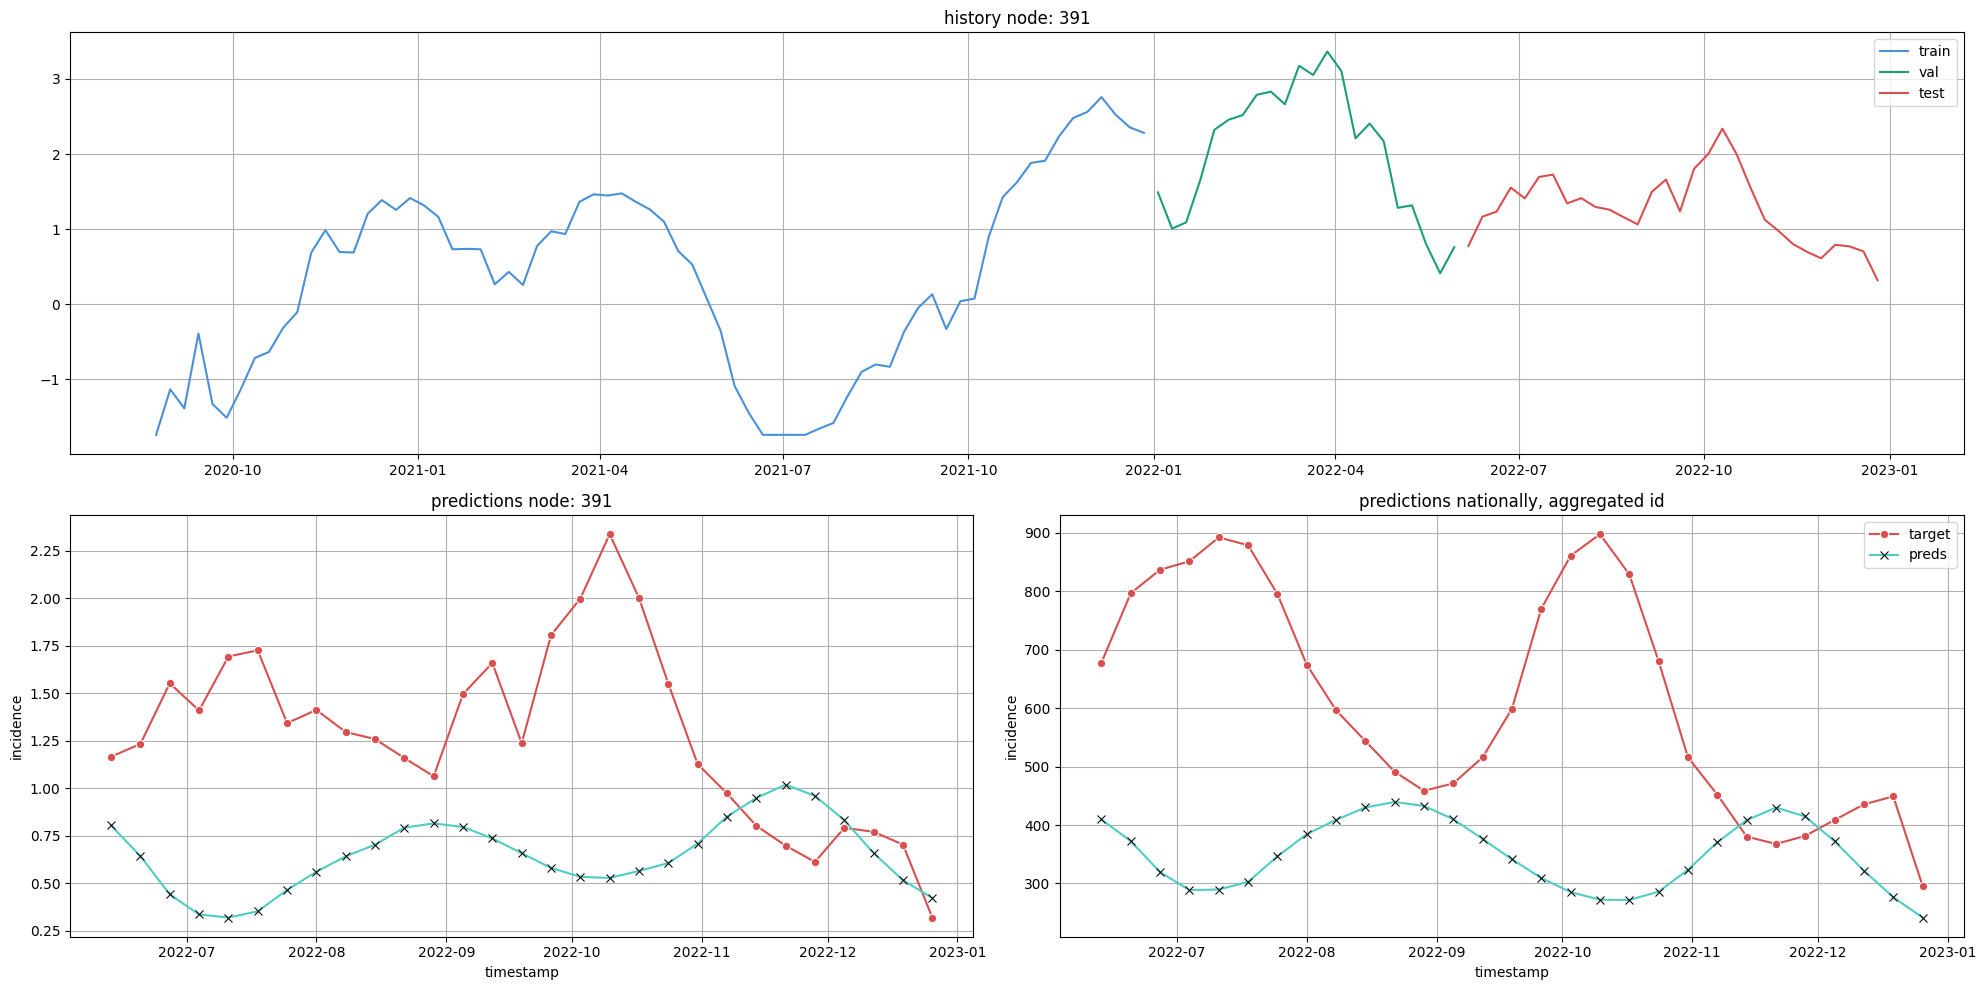

In [60]:
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors_kreis').construct_dataloaders(periods=1)
pytorch_run = PyTorchExample(name = 'id', dataloader=gnnloader2)
pytorch_run.set_model_hparams()
pytorch_run.set_global_hparams(lr = 0.0001, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001, loss = 'mse')
pytorch_run.train()
pytorch_run.forecast()
pytorch_run.show_forecasts()

In [73]:
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors_kreis').construct_dataloaders(periods=1)
pytorch_run = PyTorchExample2(name = 'id', dataloader=gnnloader2)
pytorch_run.set_model_hparams()
pytorch_run.set_global_hparams(lr = 0.0001, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001, loss = 'mse')
pytorch_run.train()
pytorch_run.forecast()
pytorch_run.show_forecasts()

single snapshot: Data(x=[399, 5, 1], edge_index=[2, 2469], y=[399], edge_weight=[2469])


  0%|                                                                                                  | 0/25 [00:00<?, ?it/s]


IndexError: index 5 is out of bounds for dimension 0 with size 5

In [ ]:
import torch
from torch.nn import functional as F

import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

from torch_geometric_temporal.nn.recurrent import DCRNN
from torch_geometric_temporal.dataset import ChickenpoxDatasetLoader
from torch_geometric_temporal.signal import temporal_signal_split


class LitDiffConvModel(pl.LightningModule):

    def __init__(self, node_features, filters):
        super().__init__()
        self.recurrent = DCRNN(node_features, filters, 1)
        self.linear = torch.nn.Linear(filters, 1)


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-2)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        x = train_batch.x
        y = train_batch.y.view(-1, 1)
        edge_index = train_batch.edge_index
        h = self.recurrent(x, edge_index)
        h = F.relu(h)
        h = self.linear(h)
        loss = F.mse_loss(h, y)
        return loss

    def validation_step(self, val_batch, batch_idx):
        x = val_batch.x
        y = val_batch.y.view(-1, 1)
        edge_index = val_batch.edge_index
        h = self.recurrent(x, edge_index)
        h = F.relu(h)
        h = self.linear(h)
        loss = F.mse_loss(h, y)
        metrics = {'val_loss': loss}
        self.log_dict(metrics)
        return metrics


loader = ChickenpoxDatasetLoader()

dataset_loader = loader.get_dataset(lags=32)

train_loader, val_loader = temporal_signal_split(dataset_loader,
                                                 train_ratio=0.2)

model = LitDiffConvModel(node_features=32,
                         filters=16)

early_stop_callback = EarlyStopping(monitor='val_loss',
                                    min_delta=0.00,
                                    patience=10,
                                    verbose=False,
                                    mode='min')

trainer = pl.Trainer(callbacks=[early_stop_callback], max_epochs= 25)

trainer.fit(model, train_loader, val_loader)


import matplotlib.pyplot as plt
import torch.nn.functional as F

# Make sure model is in eval mode
model.eval()

preds_node6 = []
targets_node6 = []

with torch.no_grad():
    for batch in val_loader:
        x = batch.x
        y = batch.y.view(-1, 1)
        edge_index = batch.edge_index
        
        h = model.recurrent(x, edge_index)
        h = F.relu(h)
        h = model.linear(h)
        
        # h shape: [num_nodes, 1]
        # Extract node 6 prediction and target
        pred_node6 = h[6].item()    # assuming node 6 exists
        target_node6 = y[6].item()
        
        preds_node6.append(pred_node6)
        targets_node6.append(target_node6)

# Plotting
plt.figure(figsize=(25, 6))
plt.plot(targets_node6, label='Target (Node 6)', marker='o')
plt.plot(preds_node6, label='Prediction (Node 6)', marker='x')
plt.title('Predictions vs Targets for Node 6 on Validation Set')
plt.xlabel('Batch index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type   | Params | Mode 
---------------------------------------------
0 | recurrent | DCRNN  | 4.7 K  | train
1 | linear    | Linear | 17     | train
---------------------------------------------
4.7 K     Trainable params
0         Non-trainable params
4.7 K     Total params
0.019     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 13: |                                                                     | 97/? [00:02<00:00, 33.17it/s, v_num=1.98e+7]


In [86]:
n_epochs = 25
epidata = EpiDataLoader('covid', data_env, aggr_level= '03', min_date='2020-07-01',max_date='2023-01-01')
# epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2022-01-01','2022-06-01','zscore')
epidata.add_lagged_features(range(1,8))

gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors_kreis').construct_dataloaders(periods=1)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [94]:

import torch
from torch.nn import functional as F

import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

from torch_geometric_temporal.nn.recurrent import DCRNN
from torch_geometric_temporal.dataset import ChickenpoxDatasetLoader
from torch_geometric_temporal.signal import temporal_signal_split


class LitDiffConvModel(pl.LightningModule):

    def __init__(self, node_features, filters):
        super().__init__()
        self.recurrent = DCRNN(node_features, filters, 1)
        self.linear = torch.nn.Linear(filters, 1)


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-2)
        return optimizer

    def training_step(self, train_batch, batch_idx=0):
        x = train_batch.x
        y = train_batch.y.view(-1, 1)
        edge_index = train_batch.edge_index
        h = self.recurrent(x, edge_index)
        h = F.relu(h)
        h = self.linear(h)
        loss = F.mse_loss(h, y)
        return loss

    def validation_step(self, val_batch, batch_idx=0):
        x = val_batch.x
        y = val_batch.y.view(-1, 1)
        edge_index = val_batch.edge_index
        h = self.recurrent(x, edge_index)
        h = F.relu(h)
        h = self.linear(h)
        loss = F.mse_loss(h, y)
        metrics = {'val_loss': loss}
        self.log_dict(metrics)
        return metrics




train_loader, val_loader = gnnloader2.dataset_train, gnnloader2.dataset_val

model = LitDiffConvModel(node_features=8,
                         filters=16)

early_stop_callback = EarlyStopping(monitor='val_loss',
                                    min_delta=0.00,
                                    patience=10,
                                    verbose=False,
                                    mode='min')

trainer = pl.Trainer(callbacks=[early_stop_callback], max_epochs= 25)

trainer.fit(model, train_loader, val_loader)


import matplotlib.pyplot as plt
import torch.nn.functional as F

# Make sure model is in eval mode
model.eval()

preds_node6 = []
targets_node6 = []

with torch.no_grad():
    for batch in val_loader:
        x = batch.x
        y = batch.y.view(-1, 1)
        edge_index = batch.edge_index
        
        h = model.recurrent(x, edge_index)
        h = F.relu(h)
        h = model.linear(h)
        
        # h shape: [num_nodes, 1]
        # Extract node 6 prediction and target
        pred_node6 = h[6].item()    # assuming node 6 exists
        target_node6 = y[6].item()
        
        preds_node6.append(pred_node6)
        targets_node6.append(target_node6)

# Plotting
plt.figure(figsize=(25, 6))
plt.plot(targets_node6, label='Target (Node 6)', marker='o')
plt.plot(preds_node6, label='Prediction (Node 6)', marker='x')
plt.title('Predictions vs Targets for Node 6 on Validation Set')
plt.xlabel('Batch index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type   | Params | Mode 
---------------------------------------------
0 | recurrent | DCRNN  | 2.4 K  | train
1 | linear    | Linear | 17     | train
---------------------------------------------
2.4 K     Trainable params
0         Non-trainable params
2.4 K     Total params
0.009     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |                                                                                      | 0/? [00:00<?, ?it/s]

RuntimeError: You provided multiple `val_dataloader`, but no `dataloader_idx` argument in `LitDiffConvModel.validation_step()`. Try adding `dataloader_idx=0` to its signature.

In [90]:
train_loader.x

tensor([[[-0.6311],
         [-1.4029],
         [-1.2141],
         ...,
         [-1.3355],
         [-1.7373],
         [-1.7373]],

        [[ 0.2726],
         [-0.9975],
         [-0.8754],
         ...,
         [-1.5394],
         [-1.3769],
         [-1.6664]],

        [[ 0.0952],
         [-1.3913],
         [-1.3355],
         ...,
         [-1.6567],
         [-1.6567],
         [-1.6961]],

        ...,

        [[-0.6906],
         [-1.7373],
         [-1.4467],
         ...,
         [-1.7373],
         [-1.7373],
         [-1.7373]],

        [[-0.5923],
         [-1.2985],
         [-1.1392],
         ...,
         [-1.7373],
         [-1.7373],
         [-1.7373]],

        [[-0.6402],
         [-1.7373],
         [-1.7373],
         ...,
         [-1.7373],
         [-1.4716],
         [-1.7373]]])